# Exercise 4

## FE class

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from plot_structure_def import plot_structure_def

def eucl_dist(p1, p2):
    x1, z1 = p1
    x2, z2 = p2
    return np.sqrt((x2-x1)**2 + (z2-z1)**2)

def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)


class Node:

    def __init__(self, x: float, z: float, fixed=None):
        self.x = x
        self.z = z
        self.fixed = fixed if fixed is not None else [] # 0 -> x fixed, 1 -> z fixed, 2 -> theta fixed
        self.dofs = []
    
    def __str__(self) -> str:
        bcond = ""
        if self.fixed is not []:
            for i in self.fixed:
                match i:
                    case 0:
                        bcond += "x "
                    case 1:
                        bcond += "z "
                    case 2:
                        bcond += "theta"
            return f"Node at x={self.x} and z={self.z} with fixed {bcond}" 
        return f"Node at x={self.x} and z={self.z}"

class Element:

    def __init__(self, n1, n2, E, I, A):
        self.n1 = n1
        self.n2 = n2
        self.E = E
        self.I = I
        self.A = A
        self.L = eucl_dist([n1.x, n1.z], [n2.x, n2.z]) # calc length
        self.psi = np.atan2(self.n2.z-self.n1.z, self.n2.x-self.n1.x) # calc angle

        Tgs = np.array([[np.cos(self.psi), np.sin(self.psi), 0], [-np.sin(self.psi), np.cos(self.psi), 0], [0, 0, 1]])

        self.Tg = np.zeros((6, 6))# global transformation mat
        self.Tg[0:3, 0:3] = Tgs
        self.Tg[3:6, 3:6] = Tgs

        k_loc = self.get_k_local()
        self.k_gl = self.Tg.T @ k_loc @ self.Tg
    
    def get_k_local(self) -> np.array:
        L, A, I, E = self.L, self.A, self.I, self.E
        mu = A*L**2/I
        k_loc = E*I/L**3 * np.array([
            [mu,  0,       0,      -mu,  0,       0     ],
            [0,   12,     -6*L,     0,  -12,     -6*L   ],
            [0,  -6*L,     4*L**2,  0,   6*L,     2*L**2],
            [-mu, 0,       0,       mu,  0,       0     ],
            [0,  -12,      6*L,     0,   12,      6*L   ],
            [0,  -6*L,     2*L**2,  0,   6*L,     4*L**2]
        ])
        
        return k_loc
    
    def __str__(self):
        return f"Element with L={self.L}, E={self.E}, I={self.I} and A={self.A} and Nodes:\n\t{self.n1.__str__()}\n\t{self.n2.__str__()}\nangle={self.psi}\n"


class NodalLoad:

    def __init__(self, node: Node, Fx=0, Fz=0, M=0):
        self.node = node
        self.Fx = Fx
        self.Fz = Fz
        self.M = M


class DistributedLoad:

    def __init__(self, element: Element, qz=0):
        # qz is the uniform load perpendicular to the local element axis (e.g., N/m)
        self.element = element
        self.qz = qz
        
    def get_equivalent_nodal_forces(self) -> np.array:
        L = self.element.L
        q = self.qz
        

        R_loc = np.array([
            0,             # local x1
            -q * L / 2,     # local z1
            q * L**2 / 12, # local theta1
            0,             # local x2
            -q * L / 2,     # local z2
            -q * L**2 / 12 # local theta2
        ])
        
        # transf local forces to global 
        R_glob = self.element.Tg.T @ R_loc
        return R_glob


class System:

    def __init__(self, elements:list, loads:list=None, nodes:list=None):
        self.elements = elements
        self.loads = loads if loads is not None else []

        if nodes is not None:
            self.nodes = nodes
        else:
            self.nodes = []

            # find unique nodes
            for el in elements:
                for candidate in (el.n1, el.n2):
                    # only add candidate if not already in
                    if candidate not in self.nodes:
                        self.nodes.append(candidate)
        
        for idx, node in enumerate(self.nodes):
            node.dofs = [0+idx*3, 1+idx*3, 2+idx*3]
        
    
    def assemble(self):
        total_dofs = 3*len(self.nodes)

        # initn displacement vecg
        self.r = np.zeros(total_dofs)

        # stiffness mat
        K_glob = np.zeros((total_dofs, total_dofs))

        for el in self.elements:
            dofs = el.n1.dofs + el.n2.dofs
            K_glob[np.ix_(dofs, dofs)] += el.k_gl
            
        self.K_glob = K_glob
        
        # force vec
        self.R_glob = np.zeros(total_dofs)

        for load in self.loads:
            if isinstance(load, NodalLoad):
                dofs = load.node.dofs
                self.R_glob[dofs[0]] += load.Fx
                self.R_glob[dofs[1]] += load.Fz
                self.R_glob[dofs[2]] += load.M

            elif isinstance(load, DistributedLoad):
                R_eq = load.get_equivalent_nodal_forces()
                dofs = load.element.n1.dofs + load.element.n2.dofs
                self.R_glob[dofs] += R_eq


    def apply_bcs(self):
        fixed_dofs = []
        for node in self.nodes:
            for fixed_idx in node.fixed:
                fixed_dofs.append(node.dofs[fixed_idx])
        
        self.K_solve = np.copy(self.K_glob)
        for dof in fixed_dofs:
            self.K_solve[dof, :] = 0.0  # zero in row
            self.K_solve[:, dof] = 0.0  # zero in col
            self.K_solve[dof, dof] = 1.0  # set diag to 1
            
            self.R_glob[dof] = 0.0 
            
        return self.K_glob, self.R_glob
    

    def solve(self):
        self.r = np.linalg.solve(self.K_solve, self.R_glob)
        return self.r

    def get_bandwidth(self):
        pass
    
    
    def __str__(self):
        elstr = ""
        for el in self.elements:
            elstr += el.__str__()

        return f"System containing {len(self.elements)} elements:\n{elstr}"


## Problem 1
### a) first numbering scheme

displacement in x at node 11 (numbering scheme 1): 0.07083672151332031


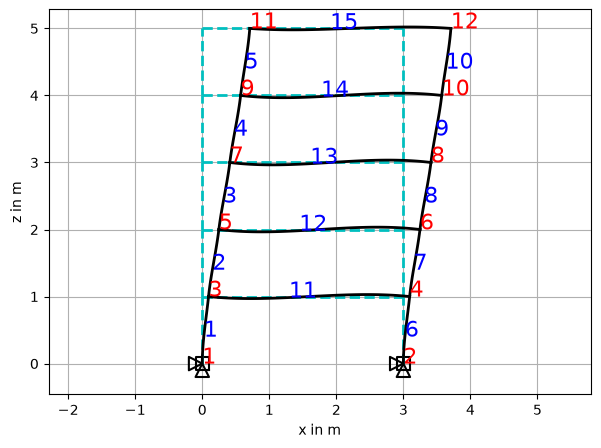

displacement vector r=
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  9.34220448e-03  1.43099283e-07
  1.03510739e-02  9.34220448e-03 -1.43099283e-07  1.03510773e-02
  2.47374450e-02  2.58595952e-07  1.21060800e-02  2.47374450e-02
 -2.58595952e-07  1.21060643e-02  4.10994817e-02  3.41810221e-07
  1.22846328e-02  4.10994817e-02 -3.41810221e-07  1.22847028e-02
  5.72089938e-02  3.92265985e-07  1.16011786e-02  5.72089937e-02
 -3.92265985e-07  1.16008674e-02  7.08367215e-02  4.11786384e-07
  7.32074553e-03  7.08360465e-02 -4.11786384e-07  7.32010291e-03]


In [9]:
a = 1 # m
E = 1e4 # Pa
Iv = 1 # m⁴     vertical stiffn = EI = 1e4
Ih = 2 # m⁴     horizontal stiffn = 2*EI = 2e4

mu = 1e6
Ah = mu*Ih/(3*a)**2 # m²
Av = mu*Iv/a**2   # m²

H = 1000 # N

n1 = Node(0, 0, fixed=[0, 1, 2])
n2 = Node(3*a, 0, fixed=[0, 1, 2])
n3 = Node(0, 1*a)
n4 = Node(3*a, 1*a)
n5 = Node(0, 2*a)
n6 = Node(3*a, 2*a)
n7 = Node(0, 3*a)
n8 = Node(3*a, 3*a)
n9 = Node(0, 4*a)
n10 = Node(3*a, 4*a)
n11 = Node(0, 5*a)
n12 = Node(3*a, 5*a)

# vertical el
el1 = Element(n1, n3, E, Iv, Av)
el2 = Element(n3, n5, E, Iv, Av)
el3 = Element(n5, n7, E, Iv, Av)
el4 = Element(n7, n9, E, Iv, Av)
el5 = Element(n9, n11, E, Iv, Av)
el6 = Element(n2, n4, E, Iv, Av)
el7 = Element(n4, n6, E, Iv, Av)
el8 = Element(n6, n8, E, Iv, Av)
el9 = Element(n8, n10, E, Iv, Av)
el10 = Element(n10, n12, E, Iv, Av)

# horizontal el
el11 = Element(n3, n4, E, Ih, Ah)
el12 = Element(n5, n6, E, Ih, Ah)
el13 = Element(n7, n8, E, Ih, Ah)
el14 = Element(n9, n10, E, Ih, Ah)
el15 = Element(n11, n12, E, Ih, Ah)

#el16 = Element(n2,n3, E, I, A)

nl11 = NodalLoad(n11, Fx=H, Fz=0, M=0)

orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15]
loads = [nl11]
sys = System(elements, loads=loads, nodes=orderednodes)

sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(f'displacement in x at node 11 (numbering scheme 1): {r[10*3]}')
fig1 = plot_structure_def(sys, 10, supports=True)
print(f'displacement vector r=\n{r}')

### b) different numbering scheme

displacement in x at node 6 (numbering scheme 2): 0.07083672151380024


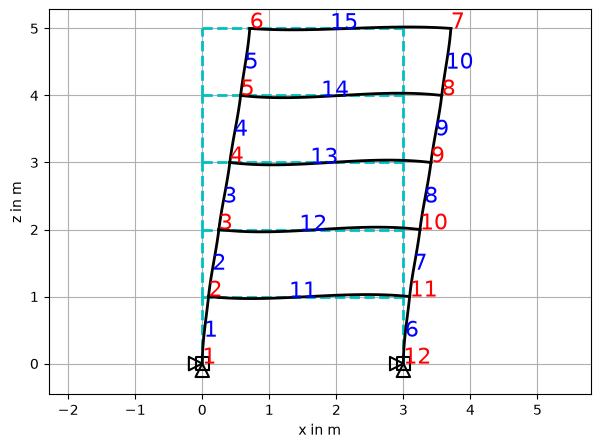

displacement vector r=
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.34220448e-03
  1.43099283e-07  1.03510739e-02  2.47374450e-02  2.58595952e-07
  1.21060800e-02  4.10994817e-02  3.41810221e-07  1.22846328e-02
  5.72089938e-02  3.92265985e-07  1.16011786e-02  7.08367215e-02
  4.11786384e-07  7.32074553e-03  7.08360465e-02 -4.11786384e-07
  7.32010291e-03  5.72089937e-02 -3.92265985e-07  1.16008674e-02
  4.10994817e-02 -3.41810221e-07  1.22847028e-02  2.47374450e-02
 -2.58595952e-07  1.21060643e-02  9.34220448e-03 -1.43099283e-07
  1.03510773e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00]


In [10]:
n1_n = Node(0, 0, fixed=[0, 1, 2])
n12_n = Node(3*a, 0, fixed=[0, 1, 2])
n2_n = Node(0, 1*a)
n11_n = Node(3*a, 1*a)
n3_n = Node(0, 2*a)
n10_n = Node(3*a, 2*a)
n4_n = Node(0, 3*a)
n9_n = Node(3*a, 3*a)
n5_n = Node(0, 4*a)
n8_n = Node(3*a, 4*a)
n6_n = Node(0, 5*a)
n7_n = Node(3*a, 5*a)

# vertical el
el1_n = Element(n1_n, n2_n, E, Iv, Av)
el2_n = Element(n2_n, n3_n, E, Iv, Av)
el3_n = Element(n3_n, n4_n, E, Iv, Av)
el4_n = Element(n4_n, n5_n, E, Iv, Av)
el5_n = Element(n5_n, n6_n, E, Iv, Av)
el6_n = Element(n12_n, n11_n, E, Iv, Av)
el7_n = Element(n11_n, n10_n, E, Iv, Av)
el8_n = Element(n10_n, n9_n, E, Iv, Av)
el9_n = Element(n9_n, n8_n, E, Iv, Av)
el10_n = Element(n8_n, n7_n, E, Iv, Av)

# horizontal el
el11_n = Element(n2_n, n11_n, E, Ih, Ah)
el12_n = Element(n3_n, n10_n, E, Ih, Ah)
el13_n = Element(n4_n, n9_n, E, Ih, Ah)
el14_n = Element(n5_n, n8_n, E, Ih, Ah)
el15_n = Element(n6_n, n7_n, E, Ih, Ah)

#el16 = Element(n2,n3, E, I, A)

nl6_n = NodalLoad(n6_n, Fx=H, Fz=0, M=0)

orderednodes = [n1_n, n2_n, n3_n, n4_n, n5_n, n6_n, n7_n, n8_n, n9_n, n10_n, n11_n, n12_n]
elements = [el1_n, el2_n, el3_n, el4_n, el5_n, el6_n, el7_n, el8_n, el9_n, el10_n, el11_n, el12_n, el13_n, el14_n, el15_n]
loads = [nl6_n]
sys_n = System(elements, loads=loads, nodes=orderednodes)

sys_n.assemble()
sys_n.apply_bcs()

r_n = sys_n.solve()
print(f'displacement in x at node 6 (numbering scheme 2): {r_n[5*3]}')
fig1 = plot_structure_def(sys_n, 10, supports=True)
print(f'displacement vector r=\n{r_n}')

### c) Sparcity stiffness matrix

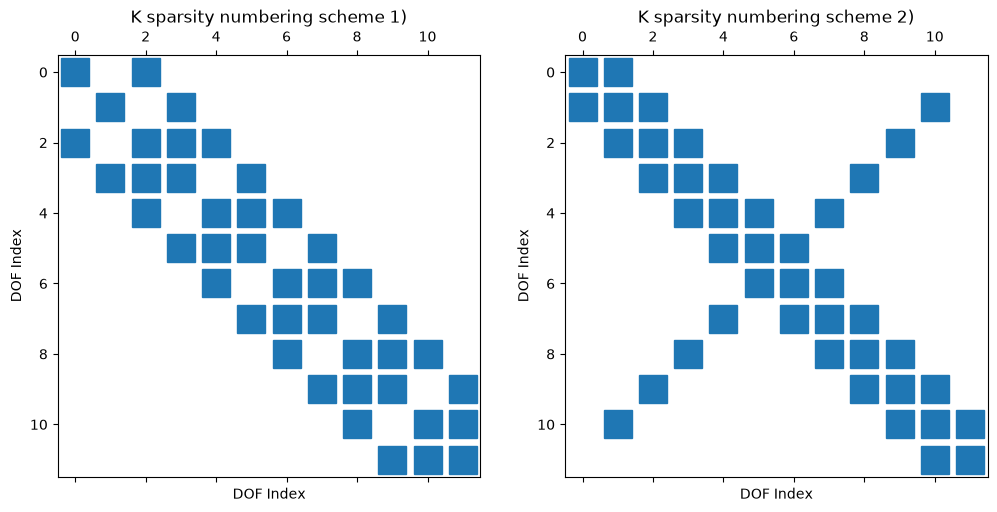

In [11]:
n_size = sys.K_solve.shape[0] // 3
K_simple = np.zeros((n_size, n_size))
K_simple_n = np.zeros((n_size, n_size))

for i in range(sys.K_glob.shape[0]):
    for j in range(sys.K_glob.shape[1]):
        if sys.K_glob[i, j] > 1e-6:
            K_simple[i // 3, j // 3] = 1
        
        if sys_n.K_glob[i, j] > 1e-6:
            K_simple_n[i // 3, j // 3] = 1

fig, ax = plt.subplots(1,2, figsize=(12,24))

ax[0].spy(K_simple, precision=0, markersize=20)
ax[0].set_title("K sparsity numbering scheme 1)")
ax[0].set_xlabel("DOF Index")
ax[0].set_ylabel("DOF Index")

ax[1].spy(K_simple_n, precision=0, markersize=20)
ax[1].set_title("K sparsity numbering scheme 2)")
ax[1].set_xlabel("DOF Index")
ax[1].set_ylabel("DOF Index")
plt.show()

### d) first numbering scheme without horizontal elements

displacement in x at node 11 without horizontal elements: 0.595239062636912


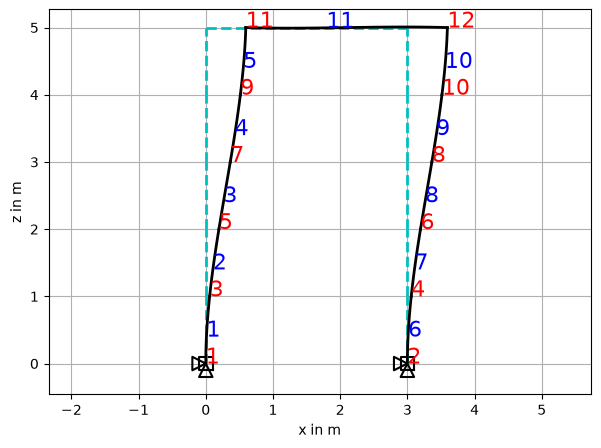

displacement vector r=
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.71429114e-02  7.93650458e-08
  1.05952486e-01  5.71428533e-02 -7.93650458e-08  1.05952377e-01
  1.95238297e-01  1.58730092e-07  1.61904948e-01  1.95238095e-01
 -1.58730092e-07  1.61904778e-01  3.64286132e-01  2.38095137e-07
  1.67857387e-01  3.64285750e-01 -2.38095137e-07  1.67857201e-01
  5.14286396e-01  3.17460183e-07  1.23809802e-01  5.14285839e-01
 -3.17460183e-07  1.23809648e-01  5.95239063e-01  3.96825229e-07
  2.97621947e-02  5.95238388e-01 -3.96825229e-07  2.97621187e-02]


In [12]:
orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el15]
loads = [nl11]
sys_s = System(elements, loads=loads, nodes=orderednodes)

sys_s.assemble()
sys_s.apply_bcs()

r_s = sys_s.solve()
print(f'displacement in x at node 11 without horizontal elements: {r_s[10*3]}')
fig1 = plot_structure_def(sys_s, 1, supports=True)
print(f'displacement vector r=\n{r_s}')

### e)

displacement in x at node 11 with additional element at 5-8: 0.04187991050259265


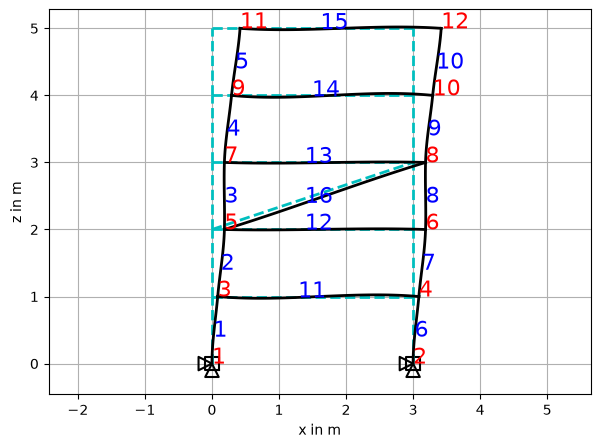

displacement vector r=
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  8.56890892e-03  1.44130363e-07
  8.87957684e-03  8.56888057e-03 -1.44130363e-07  8.72933546e-03
  1.85515273e-02  2.64782432e-07  2.47747394e-03  1.85504042e-02
 -2.64782432e-07  3.17523119e-03  1.85534655e-02  3.18082277e-07
  3.34448048e-03  1.85523414e-02 -3.77898031e-07  2.63518436e-03
  2.92137323e-02  3.63409855e-07  9.91558632e-03  2.92137060e-02
 -4.23225609e-07  1.00813451e-02  4.18799105e-02  3.82075557e-07
  7.03135514e-03  4.18792397e-02 -4.41891311e-07  6.96847059e-03]


In [13]:
el16 = Element(n5, n8, E, Iv, Av)
orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15, el16]
loads = [nl11]
sys_k = System(elements, loads=loads, nodes=orderednodes)

sys_k.assemble()
sys_k.apply_bcs()

r_k = sys_k.solve()
print(f'displacement in x at node 11 with additional element at 5-8: {r_k[10*3]}')
fig1 = plot_structure_def(sys_k, 10, supports=True)
print(f'displacement vector r=\n{r_k}')

### f) Hinge connection at node 11
Thought process in the .pdf.  
I think the visualization does not work here anymore because there is still only one dof used for the rotation, even though there would be two. So i think the value is right, but the plot is not.

displacement in x at node 11 for hinged connection: 0.08119450793762234


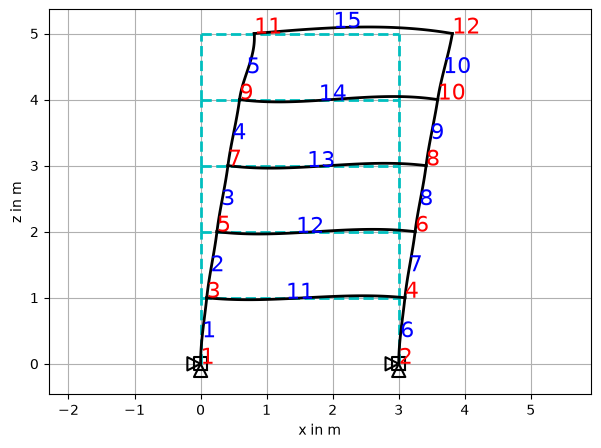

displacement vector r=
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  9.34836829e-03  1.43091067e-07
  1.03751598e-02  9.34836384e-03 -1.43091067e-07  1.03516378e-02
  2.47867283e-02  2.58546659e-07  1.21250984e-02  2.47867472e-02
 -2.58546659e-07  1.22349240e-02  4.14014412e-02  3.41522681e-07
  1.29605966e-02  4.14013577e-02 -3.41522681e-07  1.24713613e-02
  5.89833458e-02  3.90590032e-07  1.30277869e-02  5.89837171e-02
 -3.90590032e-07  1.52021165e-02  8.11945079e-02  4.02018207e-07
 -8.57086294e-03  8.11935299e-02 -4.02018207e-07  1.71425299e-02]


In [14]:
def get_hinged_k_local(el): # element k with no v_theta2, see pdf
    L, E, I, A = el.L, el.E, el.I, el.A
    mu = A*L**2/I
    k_el_h = E*I/L**3 * np.array([  [mu,  0,   0,     -mu, 0,   0],
                                    [0,   3,  -3*L,    0, -3,   0],
                                    [0,  -3*L, 3*L**2, 0,  3*L, 0],
                                    [-mu, 0,   0,      mu, 0,   0],
                                    [0,  -3,   3*L,    0,  3,   0],
                                    [0,   0,   0,      0,  0,   0]])
    return k_el_h

el5_h = Element(n9, n11, E, Iv, Av)
el5_h.k_gl = el5_h.Tg.T @ get_hinged_k_local(el5_h) @ el5_h.Tg

orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5_h, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15]
loads = [nl11]
sys_h = System(elements, loads=loads, nodes=orderednodes)


sys_h.assemble()
sys_h.apply_bcs()

r_h = sys_h.solve()
print(f'displacement in x at node 11 for hinged connection: {r_h[10*3]}')
fig1 = plot_structure_def(sys_h, 10, supports=True)
print(f'displacement vector r=\n{r_h}')